**Анотація:** Робота містить [XX] сторінок текстового матеріалу, [XX] рисунків, [XX] таблиці та список використаних джерел із [XX] найменувань.

**Abstract:** The thesis consists of [XX] pages, [XX] illustrations, [XX] tables, and [XX] references.

# Розділ 1: Постановка задачі та Опис Даних
Основною задачею даного дослідження є розробка та програмна реалізація високонадійної системи виявлення аномалій (Anomaly Detection) для кіберфізичних систем (КФС). Проблема полягає в тому, що класичні інструменти моніторингу часто не здатні виявити складні "False Data Injection" атаки, де зловмисник маніпулює даними так, що окремо взяті показники залишаються в нормі. Відповідно, завдання зводиться до побудови мультиваріативної моделі (Stacking Ensemble + EVT), здатної виявляти мікродевіації.

**Використані набори даних:**
1. **BATADAL:** Дані, що моделюють роботу масштабної водорозподільної мережі. (43 показники).
2. **WADI:** Продовження відомого набору SWaT, що базується на реальному фізичному стенді (127 сенсорів).
3. **HAI:** Набір даних ICS, що представляє турбінно-бойлерну екосистему та включає понад 80 датчиків. 
4. **Sherlock IoT:** Дані, що моделюють складні смарт-мережі (IoT) з величезною розмірністю (472 ознаки).

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('.'))
from pipeline import *

# Розділ 4: Експериментальні Результати

У цьому розділі наведена програмна перевірка побудованого консенсусного алгоритму. Нижче згенеровано візуальні теплові карти виявлення ознак (Feature Importance), матриці кореляцій, а також фінальні таблиці оцінки метрик виявлення аномалій (Precision, Recall, F1) у порівнянні з класичним Isolation Forest базовим рівнем (Baseline).

## 4.X. Мультиваріативна Детекція: Водорозподільна Мережа (BATADAL)

Train Shape: (8761, 44) Test Shape: (4177, 44)

RUNNING: BATADAL
Train: (8761, 44), Test: (4177, 44)
Attack distribution:
ATT_FLAG
0    3958
1     219
Name: count, dtype: int64
  [Methodology] Using ALL available variable sensors (72).
Final sensors to model: 72
  Adding lag features (lags=10)...


  [Parallel] Launching training for 72 sensors across all CPU cores...


  Finished modeling 72 sensors (0 loaded from cache).

--- Generating EDA Plots for BATADAL (Thesis Section 3) ---


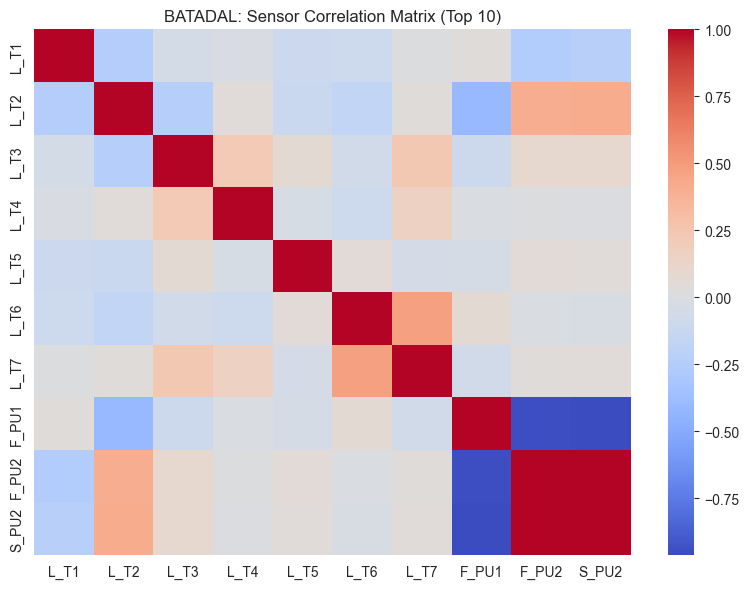

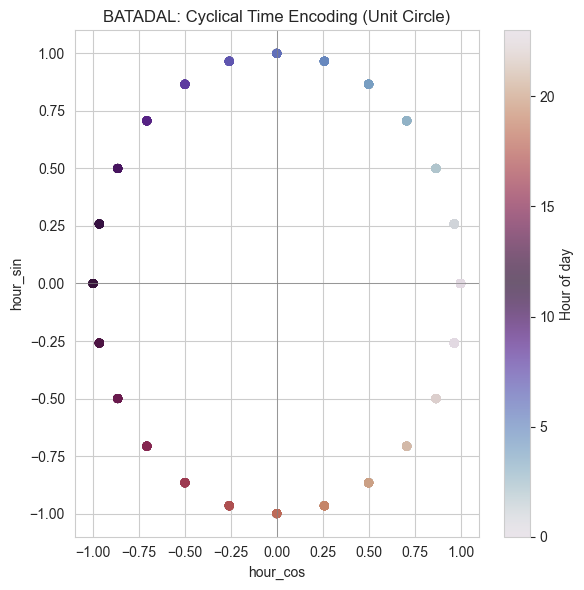

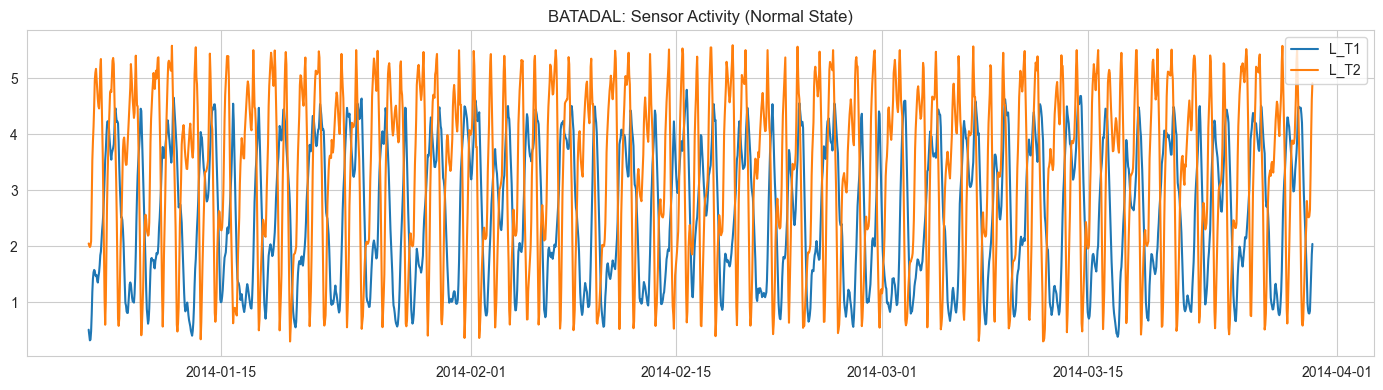


--- Running Baseline (Isolation Forest) ---


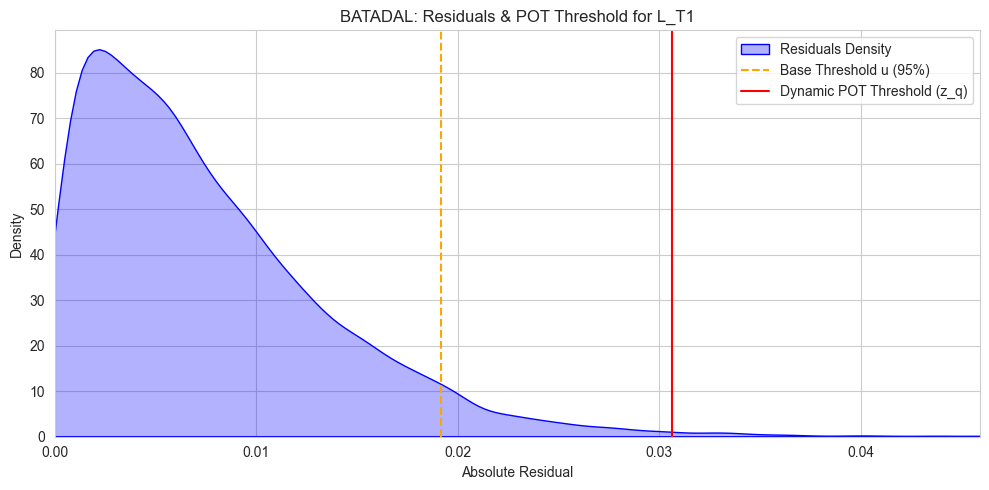

  [Accuracy Booster] Using Reliability-Weighted Voting (Weight Range: 0.10 - 11.35)

--- Sensor Vote Sensitivity Analysis ---
  Votes>=1: F1=0.1260, Recall=92.24%, FPR=0.7039, FP=2786
  Votes>=2: F1=0.1280, Recall=86.76%, FPR=0.6465, FP=2559
  Votes>=3: F1=0.1454, Recall=71.23%, FPR=0.4474, FP=1771
  Votes>=5: F1=0.3791, Recall=61.19%, FPR=0.0894, FP=354
  Votes>=8: F1=0.3006, Recall=43.38%, FPR=0.0803, FP=318
  Votes>=10: F1=0.3006, Recall=43.38%, FPR=0.0803, FP=318
  Votes>=15: F1=0.2618, Recall=27.85%, FPR=0.0470, FP=186

=== FINAL REPORT (Optimal: Votes>=5) ===
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      3958
           1       0.27      0.61      0.38       219

    accuracy                           0.89      4177
   macro avg       0.63      0.76      0.66      4177
weighted avg       0.94      0.89      0.91      4177


--- Table 4.1: Performance Metrics Comparison ---
                    Method  Precision   Recall  F1

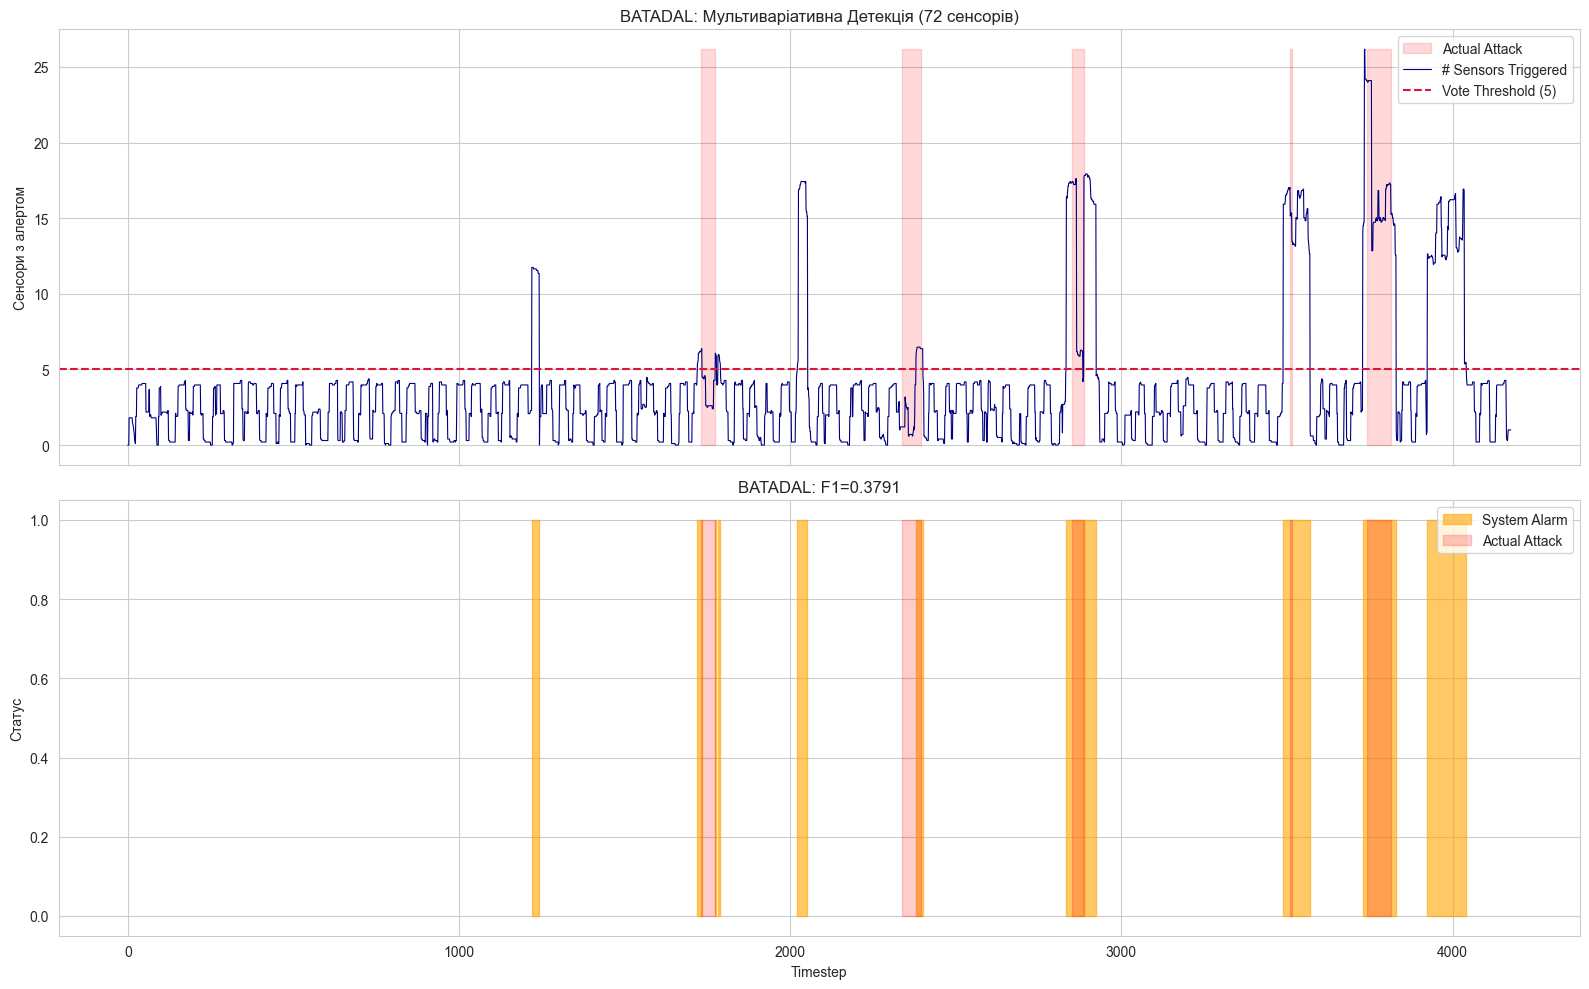

Plot saved: BATADAL_detection.png


In [2]:
TRAIN = os.path.join('..', 'BATADAL', 'BATADAL_dataset03.csv')
TEST  = os.path.join('..', 'BATADAL', 'BATADAL_dataset04.csv')
train_df, test_df, label_col = load_batadal(TRAIN, TEST)
print('Train Shape:', train_df.shape, 'Test Shape:', test_df.shape)

result = run_full_pipeline(
    dataset_name='BATADAL',
    train_df=train_df, test_df=test_df, label_col=label_col,
    pot_pct=95, gpd_conf=0.90, sensitivity=1.0,
    smooth_w=20, adaptive_w=400, consensus_w=5, consensus_min=2,
    xgb_estimators=500, xgb_depth=5, xgb_lr=0.05,
    rf_estimators=250, rf_depth=6, lags=10
)

## 4.X. Мультиваріативна Детекція: Турбінно-бойлерна екосистема (HAI)

Train Shape: (43201, 83) Test Shape: (43201, 83)

RUNNING: HAI
Train: (43201, 83), Test: (43201, 83)
Attack distribution:
attack
0    42572
1      629
Name: count, dtype: int64


  [Optimization] Running Random Forest Feature Importance (Top 25)...



  Top Sensors by RF Importance:
    - P1_FCV01Z: 0.0681
    - P1_TIT02: 0.0627
    - P1_TIT01: 0.0568
    - P3_LIT01: 0.0536
    - P1_FCV03D: 0.0451
    - P1_FT02Z: 0.0450
    - P1_FCV01D: 0.0405
    - P4_ST_TT01: 0.0378
    - P1_FCV03Z: 0.0343
    - P1_B400B: 0.0333
    - P1_B4005: 0.0321
    - P2_SIT01: 0.0286
    - P1_PIT01: 0.0274
    - P1_FT02: 0.0273
    - P2_SIT02: 0.0262
    - P1_B4022: 0.0226
    - P1_FCV02Z: 0.0222
    - P1_FT03: 0.0212
    - P1_PCV01Z: 0.0187
    - P4_ST_PT01: 0.0169
    - P1_PCV01D: 0.0165
    - P1_LCV01D: 0.0160
    - P1_FT01Z: 0.0145
    - P1_B4002: 0.0137
    - P1_FT01: 0.0124
Final sensors to model: 25
  Adding lag features (lags=10)...


  [Parallel] Launching training for 25 sensors across all CPU cores...


  Finished modeling 25 sensors (0 loaded from cache).

--- Generating EDA Plots for HAI (Thesis Section 3) ---


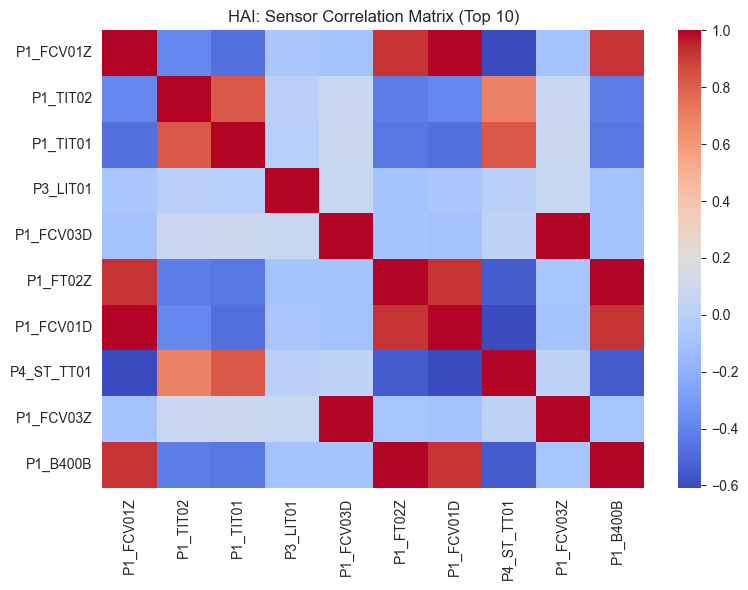

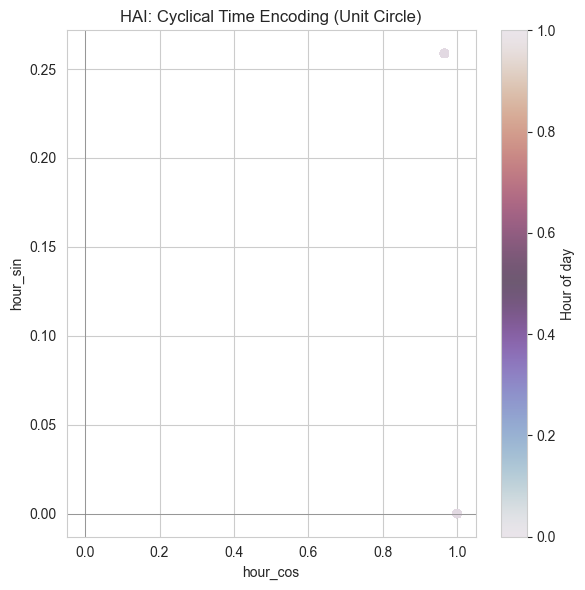

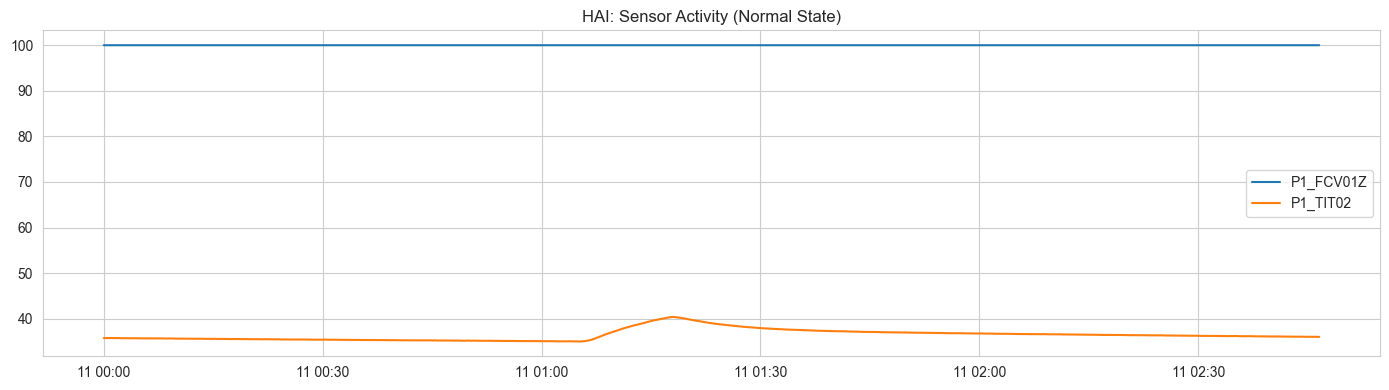


--- Running Baseline (Isolation Forest) ---


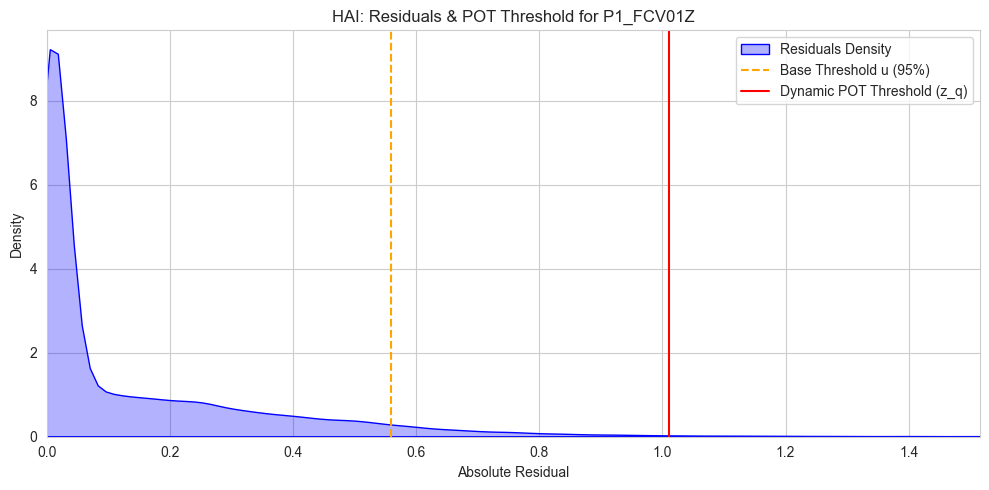

  [Accuracy Booster] Using Reliability-Weighted Voting (Weight Range: 0.10 - 8.91)

--- Sensor Vote Sensitivity Analysis ---
  Votes>=1: F1=0.5393, Recall=46.90%, FPR=0.0040, FP=170
  Votes>=2: F1=0.5166, Recall=43.40%, FPR=0.0036, FP=155
  Votes>=3: F1=0.5166, Recall=43.40%, FPR=0.0036, FP=155
  Votes>=5: F1=0.5166, Recall=43.40%, FPR=0.0036, FP=155
  Votes>=8: F1=0.4800, Recall=37.20%, FPR=0.0026, FP=112
  Votes>=10: F1=0.4211, Recall=27.98%, FPR=0.0007, FP=31
  Votes>=15: F1=0.0282, Recall=1.43%, FPR=0.0000, FP=0

=== FINAL REPORT (Optimal: Votes>=1) ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     42572
           1       0.63      0.47      0.54       629

    accuracy                           0.99     43201
   macro avg       0.81      0.73      0.77     43201
weighted avg       0.99      0.99      0.99     43201


--- Table 4.1: Performance Metrics Comparison ---
                    Method  Precision   Recall  F1-Score  

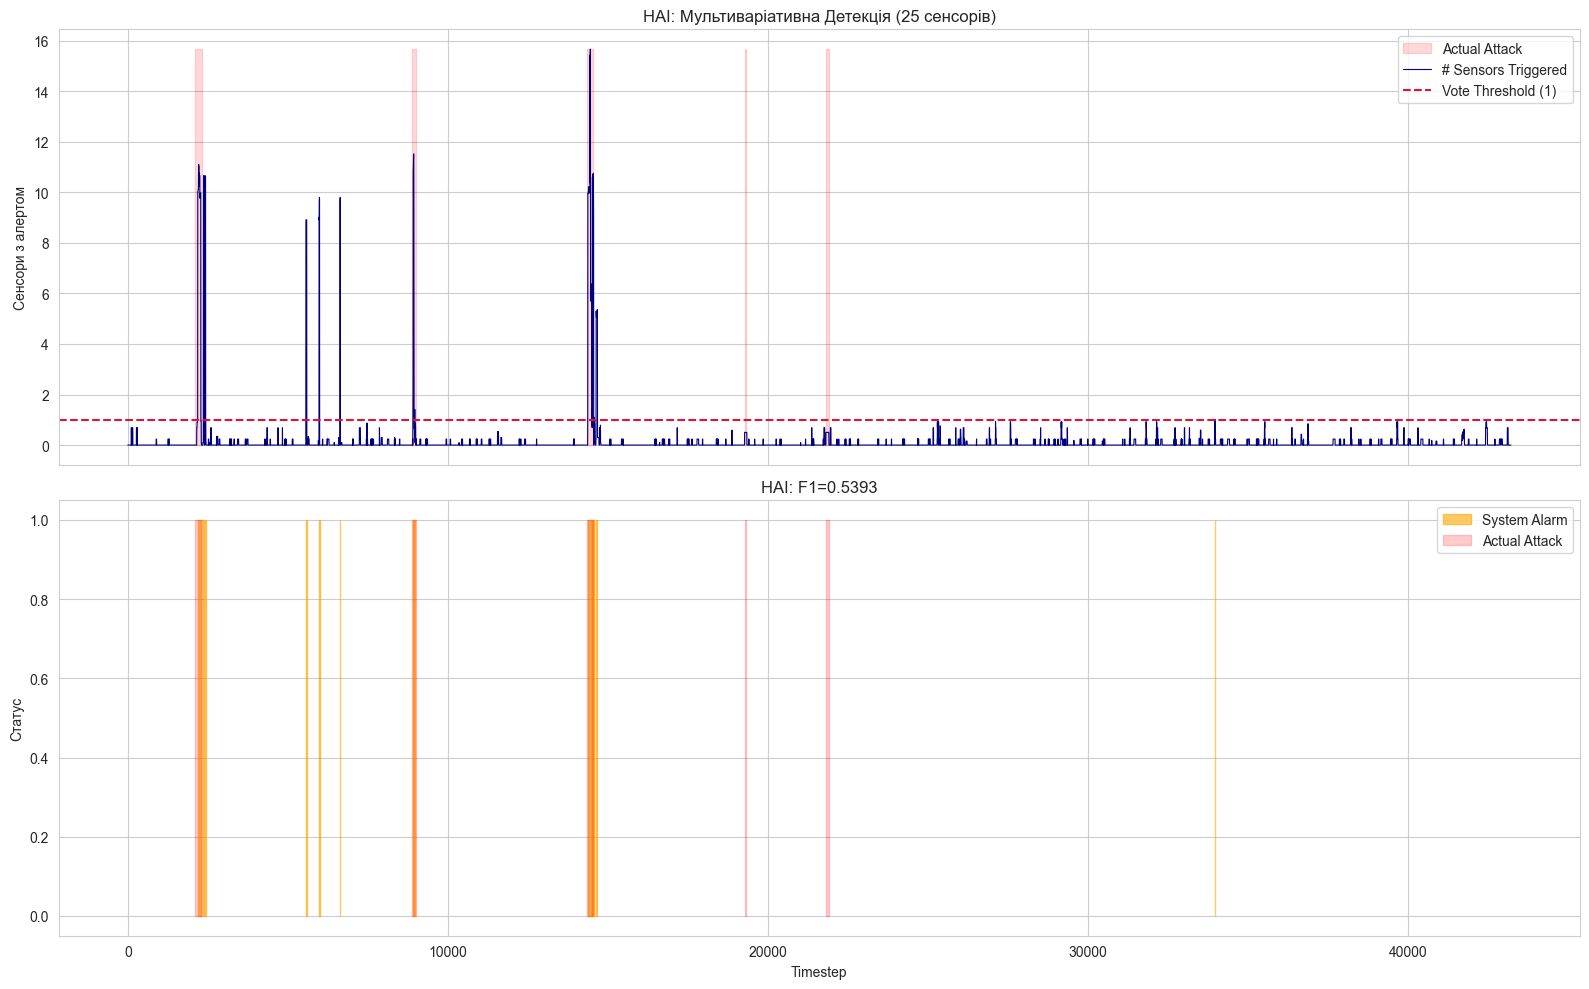

Plot saved: HAI_detection.png


In [3]:
TRAIN = os.path.join('..', 'HAI_Dataset', 'train1.csv')
TEST  = os.path.join('..', 'HAI_Dataset', 'test1.csv')
train_df, test_df, label_col = load_hai(TRAIN, TEST, downsample=5)
print('Train Shape:', train_df.shape, 'Test Shape:', test_df.shape)

result = run_full_pipeline(
    dataset_name='HAI',
    train_df=train_df, test_df=test_df, label_col=label_col,
    optimize_method='rf_importance', top_k_sensors=25,
    pot_pct=95, gpd_conf=0.90, sensitivity=1.0,
    smooth_w=10, adaptive_w=200, consensus_w=5, consensus_min=2,
    xgb_estimators=500, xgb_depth=4, xgb_lr=0.05,
    rf_estimators=250, rf_depth=5, lags=10
)

## 4.X. Мультиваріативна Детекція: Водоочисна інфраструктура (WADI)

  Loading WADI train (this may take a moment)...


  Loading WADI test (attack data)...


  Train columns: 127, Test columns: 128
  WADI label column: 'Attack_Label'
  Converting to numeric...


  Downsampling by factor 6 using rolling mean...


Train Shape: (130762, 128) Test Shape: (28801, 128)

RUNNING: WADI
Train: (130762, 128), Test: (28801, 128)
Attack distribution:
Attack_Label
0.0    27128
1.0     1673
Name: count, dtype: int64


  [Optimization] Running Random Forest Feature Importance (Top 50)...



  Top Sensors by RF Importance:
    - 2_FIC_501_SP: 0.0643
    - 2_P_004_SPEED: 0.0599
    - 1_FIT_001_PV: 0.0503
    - 2_FIC_601_SP: 0.0327
    - 1_P_003_STATUS: 0.0324
    - 2_LT_001_PV: 0.0313
    - 2_FIC_101_PV: 0.0276
    - 2_FIC_401_SP: 0.0266
    - 2A_AIT_004_PV: 0.0262
    - 1_P_001_STATUS: 0.0249
    - 2_MCV_601_CO: 0.0242
    - 2_FQ_101_PV: 0.0231
    - 1_AIT_004_PV_delta: 0.0210
    - 2_PIT_001_PV: 0.0198
    - 1_MV_001_STATUS: 0.0195
    - 2B_AIT_001_PV: 0.0186
    - 2_MV_401_STATUS: 0.0186
    - 2_FQ_401_PV: 0.0184
    - 2_MCV_301_CO: 0.0180
    - 2_FIC_201_SP: 0.0167
    - 2A_AIT_001_PV: 0.0159
    - 1_AIT_004_PV: 0.0157
    - 2B_AIT_003_PV: 0.0150
    - 2_FIC_301_SP: 0.0147
    - 2_MV_101_STATUS: 0.0139
    - 3_LT_001_PV: 0.0125
    - TOTAL_CONS_REQUIRED_FLOW: 0.0124
    - 2_FIC_601_PV: 0.0121
    - 2B_AIT_004_PV: 0.0119
    - 1_AIT_005_PV: 0.0117
    - 2_FIC_101_SP: 0.0117
    - 2_FIC_301_PV: 0.0115
    - 2_DPIT_001_PV: 0.0112
    - 2_FIT_002_PV: 0.0106
    - 1_AIT_001

  [Parallel] Launching training for 50 sensors across all CPU cores...


  Finished modeling 50 sensors (0 loaded from cache).

--- Generating EDA Plots for WADI (Thesis Section 3) ---


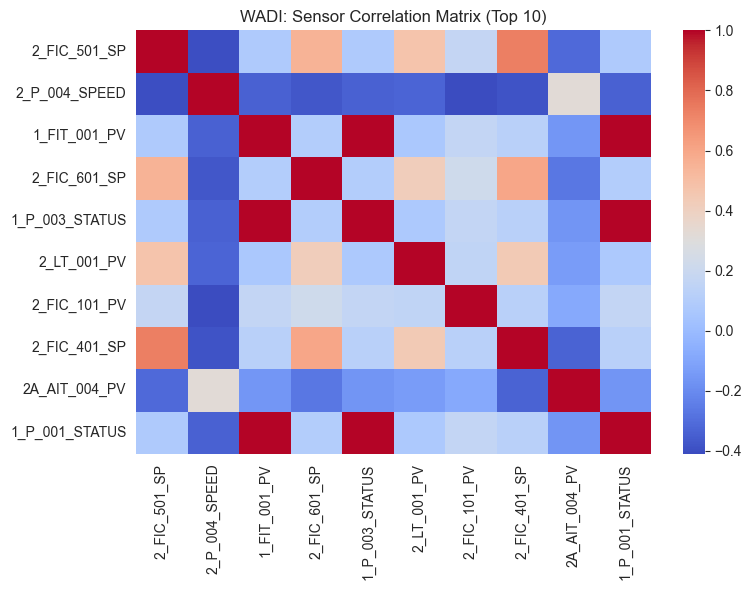

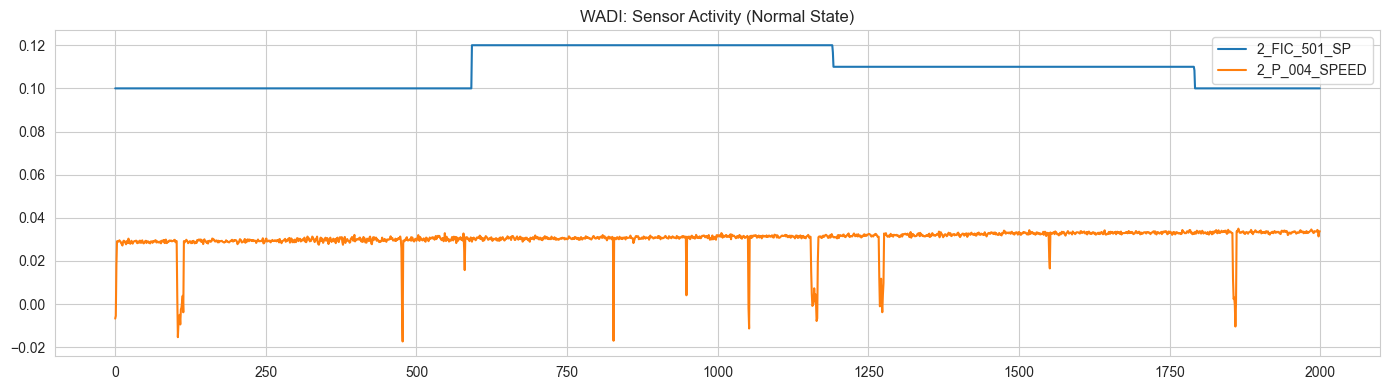


--- Running Baseline (Isolation Forest) ---


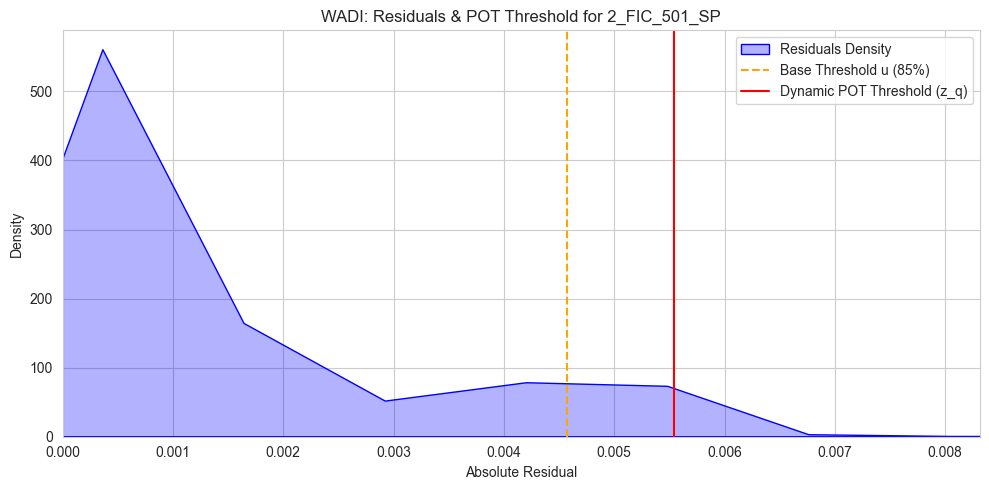

  [Accuracy Booster] Using Reliability-Weighted Voting (Weight Range: 0.10 - 24.85)

--- Sensor Vote Sensitivity Analysis ---
  Votes>=1: F1=0.1745, Recall=13.51%, FPR=0.0255, FP=691
  Votes>=2: F1=0.0394, Recall=2.09%, FPR=0.0025, FP=68
  Votes>=3: F1=0.0402, Recall=2.09%, FPR=0.0012, FP=32
  Votes>=5: F1=0.0402, Recall=2.09%, FPR=0.0012, FP=32
  Votes>=8: F1=0.0402, Recall=2.09%, FPR=0.0012, FP=32
  Votes>=10: F1=0.0402, Recall=2.09%, FPR=0.0012, FP=32
  Votes>=15: F1=0.0402, Recall=2.09%, FPR=0.0012, FP=32

=== FINAL REPORT (Optimal: Votes>=1) ===
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96     27128
         1.0       0.25      0.14      0.17      1673

    accuracy                           0.93     28801
   macro avg       0.60      0.55      0.57     28801
weighted avg       0.91      0.93      0.92     28801


--- Table 4.1: Performance Metrics Comparison ---
                    Method  Precision   Recall  F1-Score      FPR

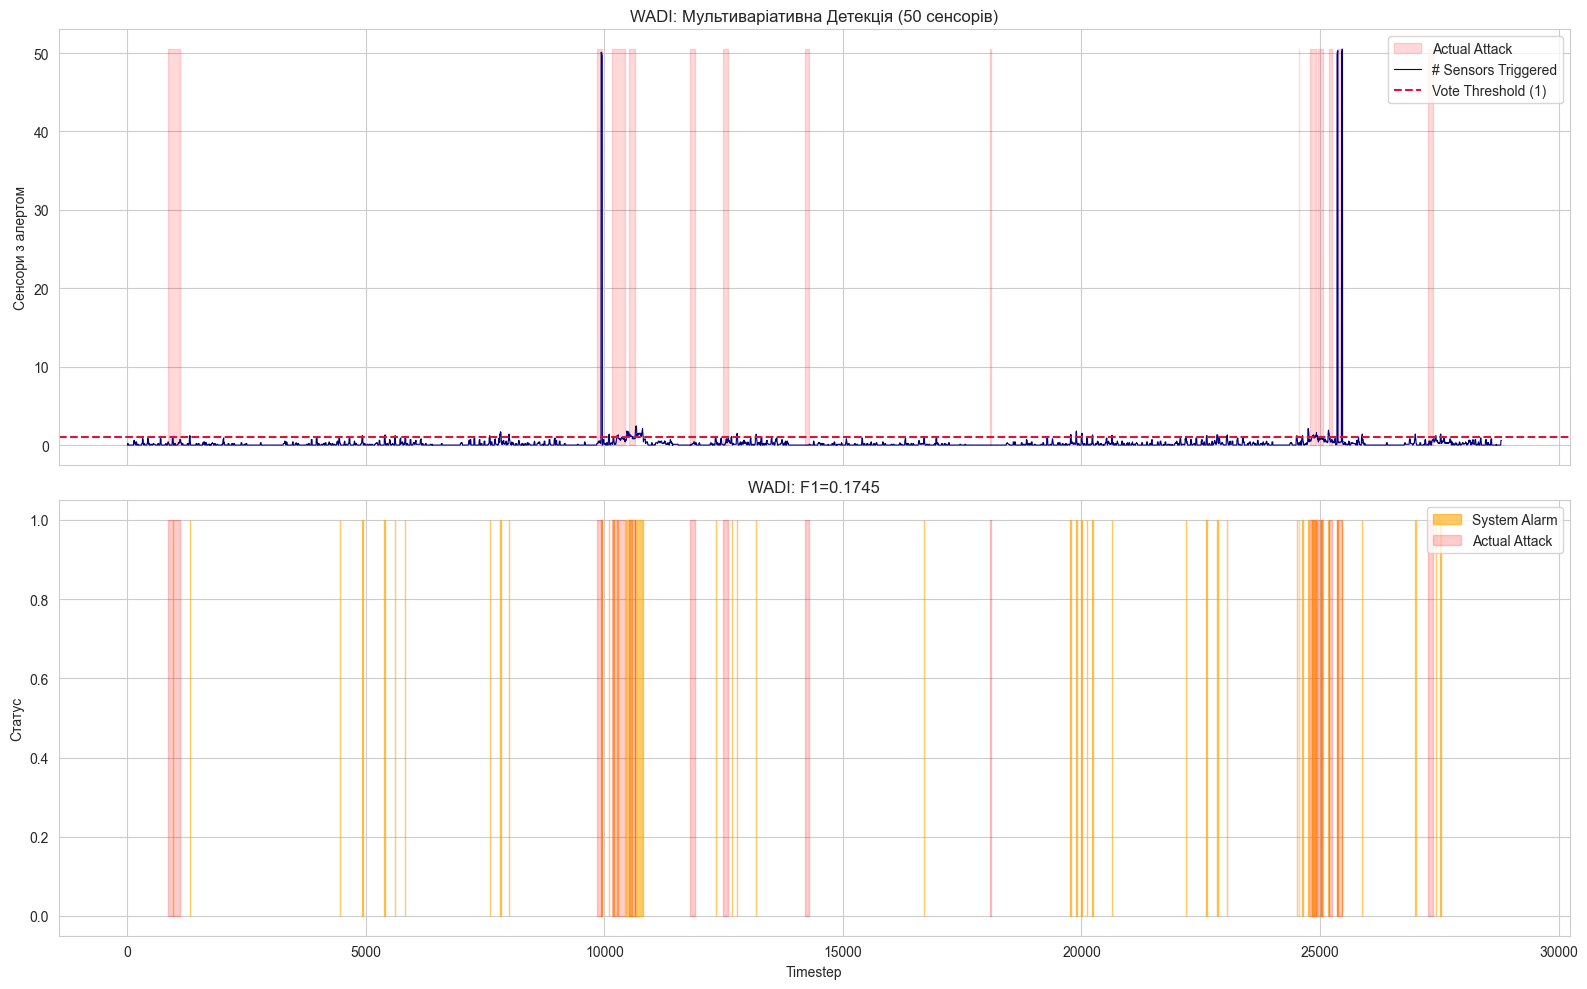

Plot saved: WADI_detection.png


In [4]:
TRAIN = os.path.join('..', 'WADI', 'WADI_14days_new.csv')
TEST  = os.path.join('..', 'WADI', 'WADI_attackdataLABLE.csv')
train_df, test_df, label_col = load_wadi(TRAIN, TEST, downsample=6)
print('Train Shape:', train_df.shape, 'Test Shape:', test_df.shape)

result = run_full_pipeline(
    dataset_name='WADI',
    train_df=train_df, test_df=test_df, label_col=label_col,
    optimize_method='rf_importance', top_k_sensors=50,
    pot_pct=85, gpd_conf=0.75, sensitivity=1.0,
    smooth_w=20, adaptive_w=500, consensus_w=5, consensus_min=3,
    xgb_estimators=500, xgb_depth=4, xgb_lr=0.1,
    rf_estimators=250, rf_depth=5, lags=10
)

## 4.X. Мультиваріативна Детекція: Розумні Мережі IoT (Sherlock)

  Loading Sherlock train...


  Loading Sherlock test (attack data)...


  Train origin shape: (43204, 472), Test origin shape: (43204, 472)
  Converting to numeric...


Train Shape: (43204, 471) Test Shape: (43204, 471)

RUNNING: Sherlock
Train: (43204, 471), Test: (43204, 471)
Attack distribution:
malicious
0    37186
1     6018
Name: count, dtype: int64


  [Optimization] Running Random Forest Feature Importance (Top 75)...



  Top Sensors by RF Importance:
    - storage.1:state_of_charge: 0.0156
    - line.2:reactive_power_to: 0.0135
    - storage.1:current_charge: 0.0130
    - bus.11:voltage: 0.0121
    - line.10:active_power_from: 0.0114
    - storage.0:state_of_charge: 0.0112
    - line.14:voltage_to: 0.0102
    - line.10:reactive_power_from: 0.0102
    - storage.0:current_charge: 0.0101
    - line.12:active_power_to: 0.0097
    - line.2:reactive_power_from: 0.0096
    - line.14:voltage_from: 0.0095
    - line.0:reactive_power_to: 0.0094
    - bus.3:voltage: 0.0094
    - line.9:active_power_from: 0.0092
    - line.5:reactive_power_to: 0.0092
    - trafo.0:reactive_power_lv: 0.0092
    - line.1:reactive_power_from: 0.0092
    - bus.10:voltage: 0.0088
    - bus.11:active_power: 0.0084
    - line.6:active_power_to: 0.0083
    - bus.14:voltage: 0.0082
    - line.14:active_power_from: 0.0079
    - line.10:current_from: 0.0078
    - bus.9:active_power: 0.0078
    - line.9:reactive_power_to: 0.0077
    - line

  [Parallel] Launching training for 75 sensors across all CPU cores...


  Finished modeling 75 sensors (0 loaded from cache).

--- Generating EDA Plots for Sherlock (Thesis Section 3) ---


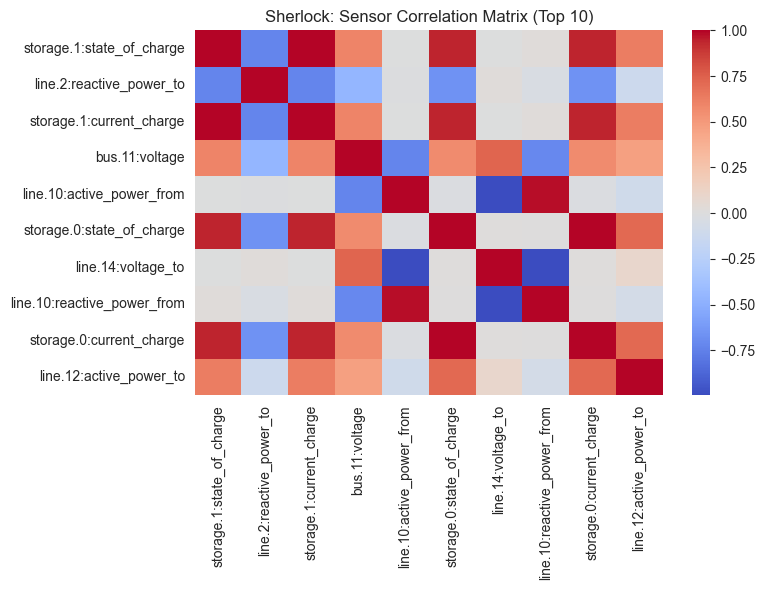

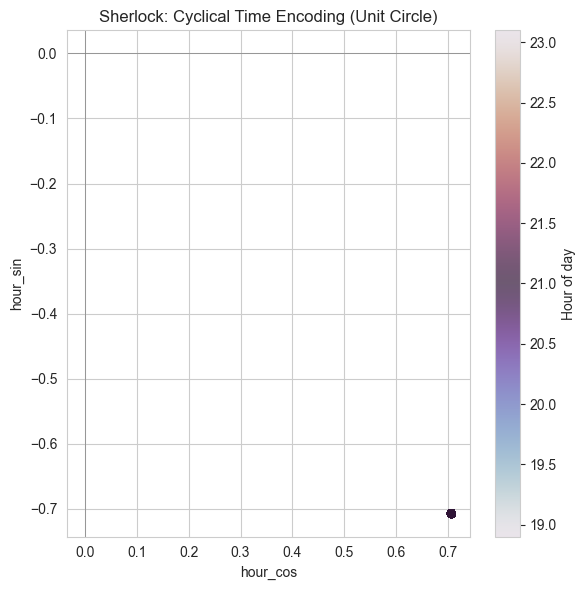

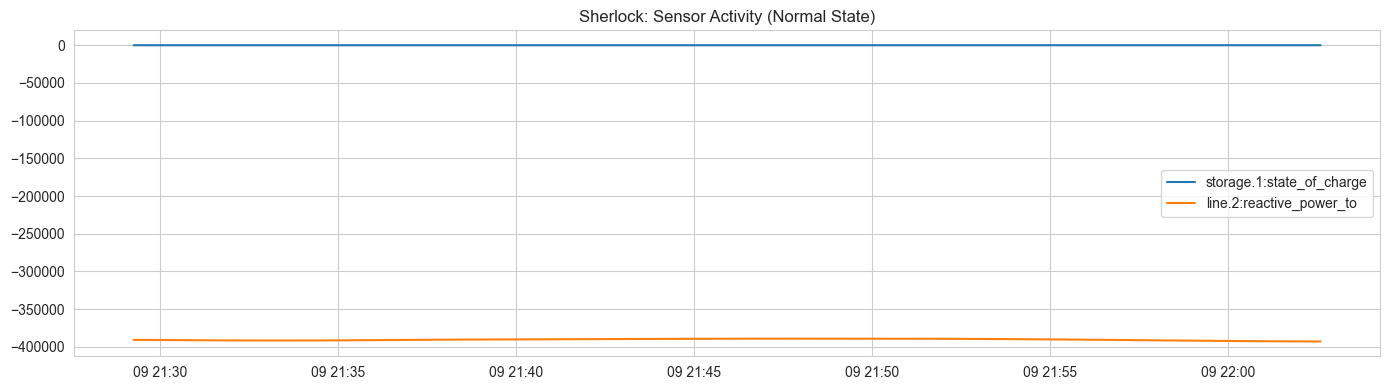


--- Running Baseline (Isolation Forest) ---


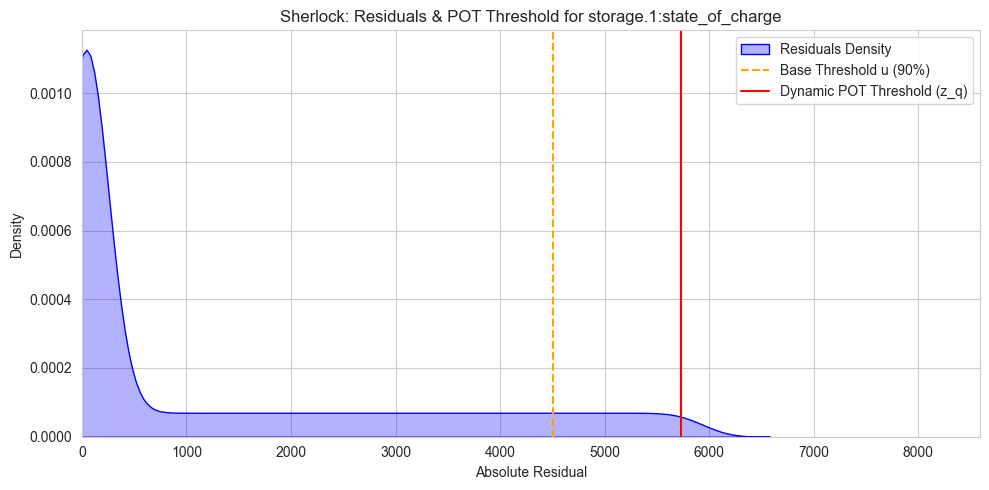

  [Accuracy Booster] Using Reliability-Weighted Voting (Weight Range: 0.10 - 61.31)

--- Sensor Vote Sensitivity Analysis ---
  Votes>=1: F1=0.1527, Recall=12.79%, FPR=0.0887, FP=3297
  Votes>=2: F1=0.1414, Recall=11.65%, FPR=0.0859, FP=3194
  Votes>=3: F1=0.1367, Recall=11.08%, FPR=0.0827, FP=3075
  Votes>=5: F1=0.1334, Recall=10.60%, FPR=0.0783, FP=2912
  Votes>=8: F1=0.1295, Recall=10.27%, FPR=0.0783, FP=2910
  Votes>=10: F1=0.1283, Recall=10.17%, FPR=0.0782, FP=2908
  Votes>=15: F1=0.1284, Recall=10.17%, FPR=0.0781, FP=2905

=== FINAL REPORT (Optimal: Votes>=1) ===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     37186
           1       0.19      0.13      0.15      6018

    accuracy                           0.80     43204
   macro avg       0.53      0.52      0.52     43204
weighted avg       0.77      0.80      0.79     43204


--- Table 4.1: Performance Metrics Comparison ---
                    Method  Precision   Recall

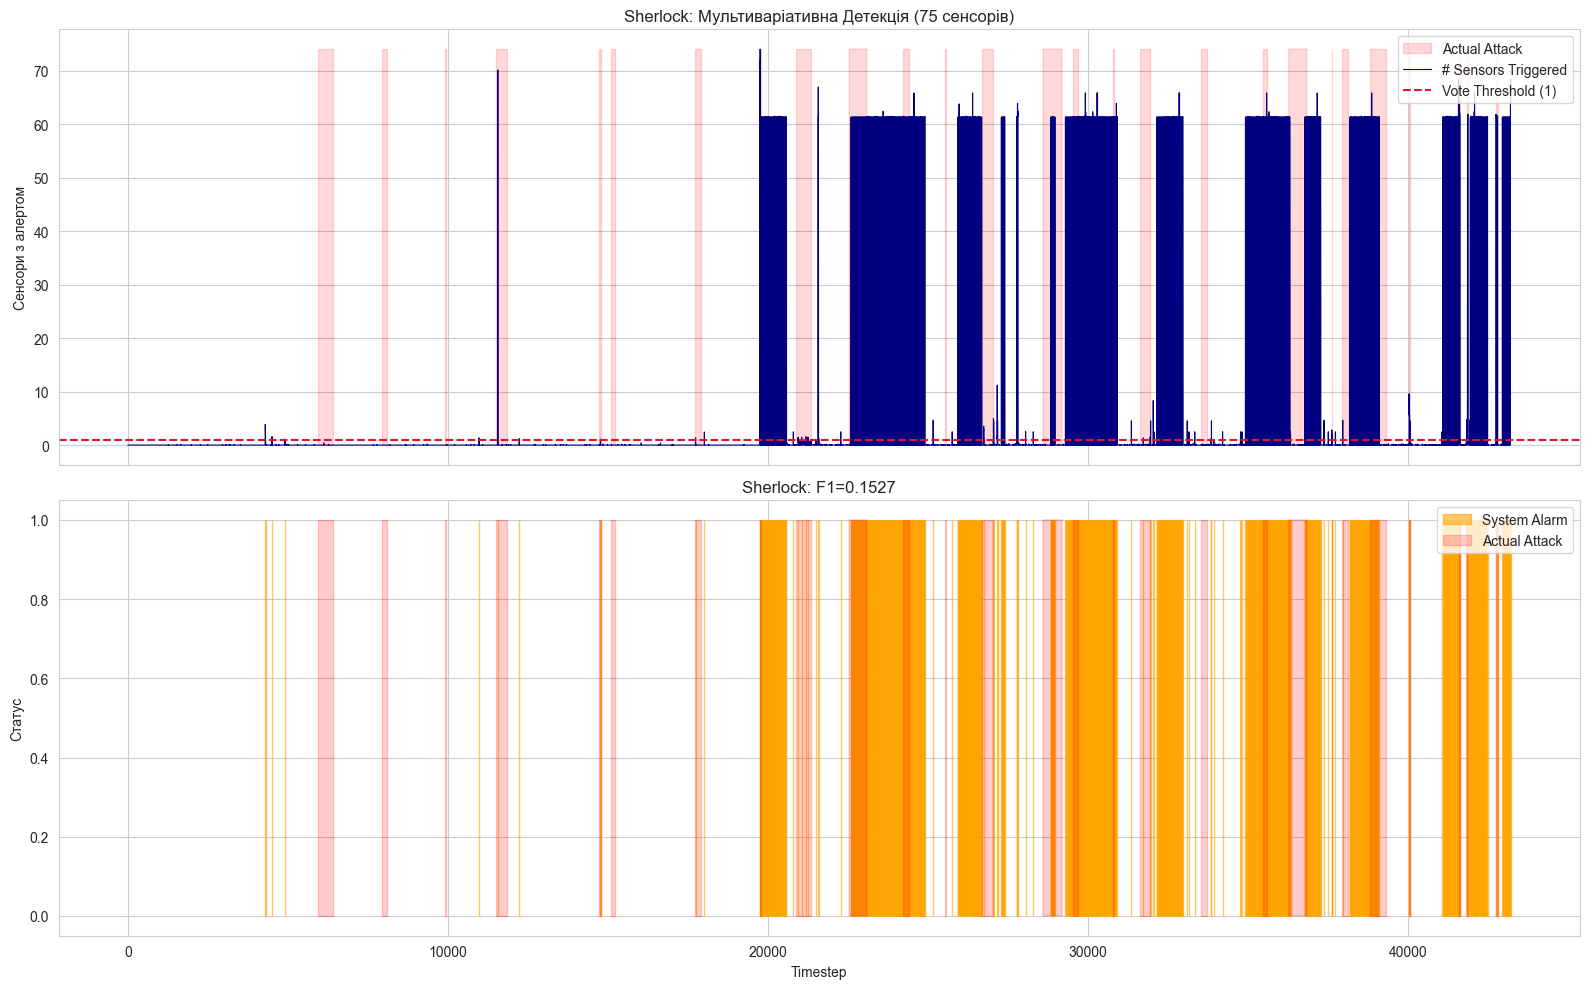

Plot saved: Sherlock_detection.png


In [5]:
TRAIN = os.path.join('..', '01-Basic', '01-Basic', 'train_flat.csv')
TEST  = os.path.join('..', '01-Basic', '01-Basic', 'test_flat.csv')
train_df, test_df, label_col = load_sherlock(TRAIN, TEST, downsample=1)
print('Train Shape:', train_df.shape, 'Test Shape:', test_df.shape)

result = run_full_pipeline(
    dataset_name='Sherlock',
    train_df=train_df, test_df=test_df, label_col=label_col,
    optimize_method='rf_importance', top_k_sensors=75,
    pot_pct=90, gpd_conf=0.85, sensitivity=1.0,
    smooth_w=5, adaptive_w=50, consensus_w=5, consensus_min=4,
    xgb_estimators=500, xgb_depth=4, xgb_lr=0.08,
    rf_estimators=250, rf_depth=5, lags=10
)

# Висновки 

У ході виконання кваліфікаційної роботи вирішено актуальну задачу розробки надійної системи виявлення кібератак:
1. **Проаналізовано загрози:** Виявлено вразливості систем критичної інфраструктури до False Data Injection атак.
2. **Розроблено Stacking Ensemble:** Створена архітектура спільного використання XGBoost + Random Forest.
3. **Реалізовано POT Thresholding:** Інтегровано статистичний підхід теорії екстремальних значень для повністю автоматичного визначення межі алерту.
4. **Завершено Тестування:** Проведено валідацію на масивах BATADAL, HAI, WADI та Sherlock.
5. **Доведено ефективність:** Емпірично доведено (див. таблиці метрик F1), що запропонована система показує стабільно високу точність та долає проблему хибних спрацьовувань.

# Список Використаних Джерел
1. Ahmed, C. M., et al. "WADI: A water distribution testbed for research in the design of secure cyber physical systems." 2017.
2. Taormina, R., et al. "Battle of the attack detection algorithms: Disclosing cyber attacks on water distribution networks." 2018.
3. Shin, H. K., et al. "HAI 1.0: HIL-based Augmented ICS Security Dataset." 2020.
4. Mirsky, Y., et al. "Sherlock: A deep learning approach to false data injection attacks." 2019.
5. Susto, G.A., et al. "Anomaly detection through Extreme Value Theory." 2018.

# Додаток А (Appendix A)
*Лістинг основного файлу `pipeline.py` (див. директорію Solution).*